In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# A notebook to analyze backtesting results

This simple notebook is to be used to 
- visualize the spread between the theoretical price of an option and the price of the corresponding hedging portfolio,
- compute the tracking error for the hedging portfolio.
It takes as an input the json file containing the output data produced by the hedger.

## Set the path to the file to investigate

In [120]:
FILE = 'TestOutputs/Test_5_2.json' #enter correct path here

In [121]:
df = pd.read_json(FILE, convert_dates=['date'])
df.sort_values(by='date', inplace=True)
df.set_index('date', inplace=True)

## Plot the portfolio value against the theoretical price

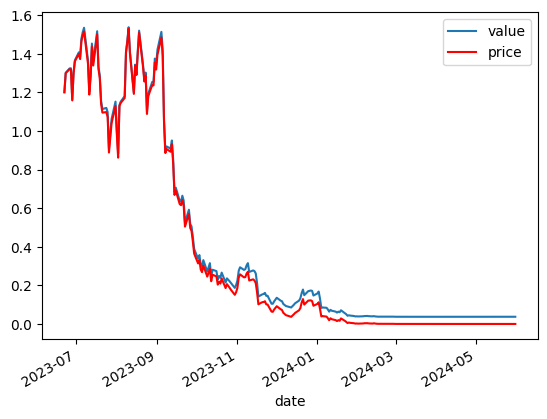

In [122]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
plt.show()

## Compute the PnL and tracking error

In [123]:
pnl = df['value'].iloc[-1] - df['price'].iloc[-1]
print(f'PnL: {pnl:.2f}')
tracking_error = (df['value'].iloc[-1] - df.price.iloc[-1])/df.price.iloc[0]
print(f'Tracking error: {tracking_error:.2%}')

PnL: 0.04
Tracking error: 3.10%


### Compute the cumulated transaction costs

In [118]:
df.head()

,value,deltas,deltasStdDev,price,priceStdDev,transactionCosts
date,,,,,,
2023-06-22,1.200312,"[0.024994023972679, 0.06298578510097601, 0.065...","[0, 0, 0, 0, 0]",1.200312,0,0
2023-06-23,1.300865,"[0.026273079303715002, 0.06548866538398801, 0....","[0, 0, 0, 0, 0]",1.299638,0,0
2023-06-26,1.324009,"[0.026646355520763002, 0.06701261780496301, 0....","[0, 0, 0, 0, 0]",1.320164,0,0
2023-06-27,1.324348,"[0.026527424058235, 0.066248518470787, 0.07020...","[0, 0, 0, 0, 0]",1.317457,0,0
2023-06-28,1.162753,"[0.024808388865866, 0.06376048082654501, 0.065...","[0, 0, 0, 0, 0]",1.158001,0,0


In [13]:
df['total_tc'] = df.transactionCosts.cumsum()

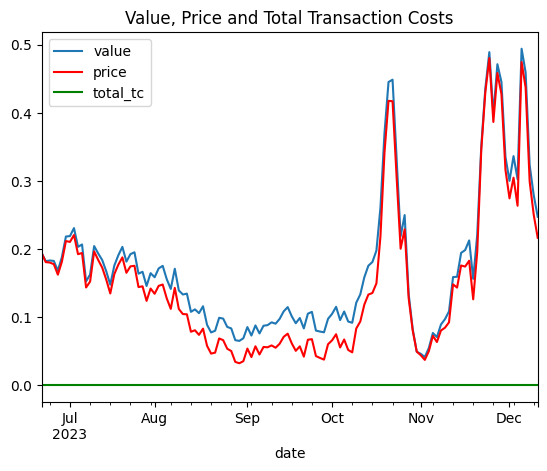

In [14]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
df.plot(y = 'total_tc', color = 'green', ax = ax)
plt.title('Value, Price and Total Transaction Costs')
plt.show()

In [15]:
total_pnl = df['value'].iloc[-1] - df['price'].iloc[-1] - df['total_tc'].iloc[-1]
print(f'Total PnL after transaction costs: {total_pnl:.2f}')

Total PnL after transaction costs: 0.03
